In [15]:
import numpy as np
import pandas as pd


In [16]:
class BatchGD:
    def __init__(self , learning_rate = 0.01 , epochs = 1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.intercept = None
        
    def fit(self , X ,y):
        X = np.asarray(X)
        y = np.asarray(y)
        
        self.weights = np.zeros(X.shape[1])
        self.intercept = 0
        
        for i in range(self.epochs):
            y_pred = X@self.weights + self.intercept
            slope_weight = (2/X.shape[0]) * (X.T @(y_pred - y))
            slope_intercept = (2/X.shape[0]) * np.sum(y_pred - y)
            
            self.weights = self.weights - self.learning_rate*slope_weight
            self.intercept = self.intercept - self.learning_rate*slope_intercept
            
        return self.weights , self.intercept
    
    def predict(self , X):
        return np.asarray(X) @ self.weights + self.intercept

In [17]:
import seaborn as sns
df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
X = df.drop(columns='tip')
y= df['tip']

category_columns = ['sex' , 'smoker' , 'day' , 'time']
numerical_columns = ['total_bill' , 'size']

trf = ColumnTransformer([
    ("one hot encode" , OneHotEncoder() ,category_columns),("scaler" , StandardScaler() , numerical_columns)
] , remainder=  'passthrough')

In [20]:
from sklearn.model_selection import train_test_split
X_train , X_test ,y_train ,y_test = train_test_split(X , y , test_size=0.2)
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import r2_score


gd = BatchGD(learning_rate=0.01, epochs=1000)
gd.fit(X_train_transformed, y_train)

y_pred_gd = gd.predict(X_test_transformed)

lr = LinearRegression()
lr.fit(X_train_transformed, y_train)

y_pred_lr = lr.predict(X_test_transformed)


sgd = SGDRegressor()
sgd.fit(X_train_transformed, y_train)

y_pred_sgd = sgd.predict(X_test_transformed)

print("Batch GD R2:", r2_score(y_test, y_pred_gd))
print("Sklearn R2:", r2_score(y_test, y_pred_lr))
print("Sklearn sgd R2:", r2_score(y_test, y_pred_sgd))


Batch GD R2: 0.30068354984931644
Sklearn R2: 0.303403449900983
Sklearn sgd R2: 0.28672346207526234


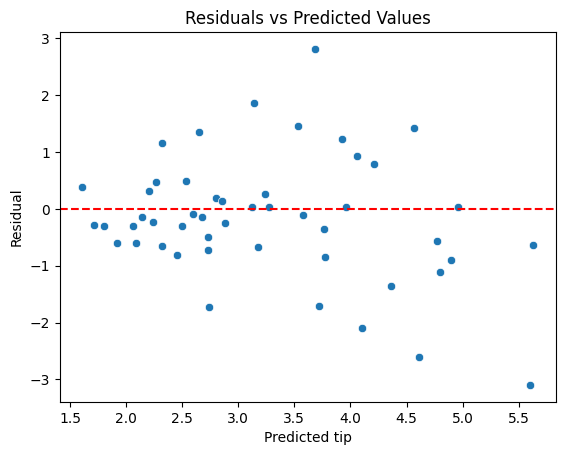

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_transformed, y_train)

y_pred = model.predict(X_test_transformed)
residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted tip")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")
plt.show()